In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# 1. Dados
df       = yf.download("PETR4.SA", start="2015-01-01", end="2026-01-01", auto_adjust=True)
close    = df["Close"].squeeze()
retornos = np.log(close / close.shift(1)).dropna()
retornos.name = "log_return"
display(retornos.describe())

[*********************100%***********************]  1 of 1 completed


count    2736.000000
mean        0.000919
std         0.029056
min        -0.352367
25%        -0.011877
50%         0.001133
75%         0.014857
max         0.200671
Name: log_return, dtype: float64

In [7]:
# 2. VaR histórico (referência)
alpha    = 0.05
var_hist = retornos.quantile(alpha)
print(f"VaR 95%: {var_hist:.4f}  ({var_hist:.2%})")

VaR 95%: -0.0418  (-4.18%)


In [8]:
# 3. CVaR histórico
# média dos retornos que ficaram abaixo do VaR (os piores alpha%)
cvar_hist = retornos[retornos <= var_hist].mean()
print(f"CVaR 95%: {cvar_hist:.4f}  ({cvar_hist:.2%})")

CVaR 95%: -0.0688  (-6.88%)


In [9]:
# 4. CVaR paramétrico (distribuição normal)
# E[R | R <= q_α] = μ - σ · φ(z_α) / α
mu    = retornos.mean()
sigma = retornos.std()
z     = stats.norm.ppf(alpha)

var_param  = mu + sigma * z
cvar_param = mu - sigma * stats.norm.pdf(z) / alpha

print(f"VaR  95% (normal): {var_param:.4f}  ({var_param:.2%})")
print(f"CVaR 95% (normal): {cvar_param:.4f}  ({cvar_param:.2%})")

VaR  95% (normal): -0.0469  (-4.69%)
CVaR 95% (normal): -0.0590  (-5.90%)


In [10]:
# 5. Múltiplos níveis de confiança
rows = []
for conf in [0.90, 0.95, 0.99]:
    a  = 1 - conf
    z  = stats.norm.ppf(a)
    vh = retornos.quantile(a)
    ch = retornos[retornos <= vh].mean()
    vp = mu + sigma * z
    cp = mu - sigma * stats.norm.pdf(z) / a
    rows.append({"Confiança": f"{conf:.0%}", "VaR Hist": vh, "CVaR Hist": ch, "VaR Param": vp, "CVaR Param": cp})

display(pd.DataFrame(rows).set_index("Confiança").round(4))

,VaR Hist,CVaR Hist,VaR Param,CVaR Param
Confiança,,,,
90%,-0.0289,-0.0518,-0.0363,-0.0501
95%,-0.0418,-0.0688,-0.0469,-0.0590
99%,-0.0790,-0.1271,-0.0667,-0.0765


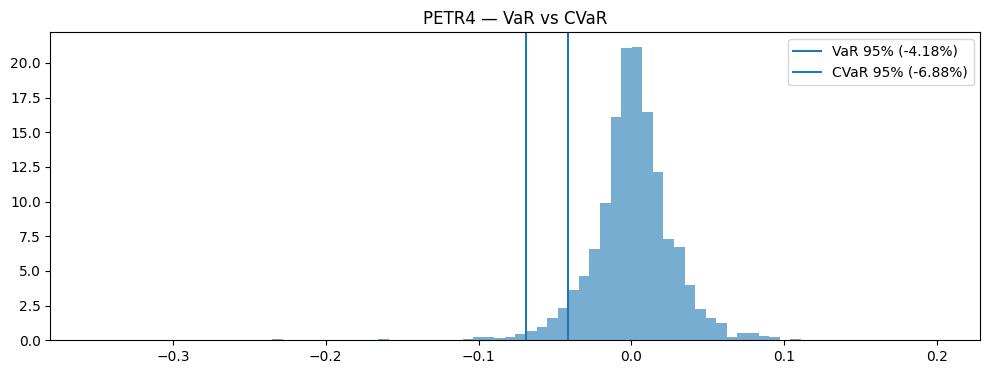

In [14]:
# 6. Visualização
plt.figure(figsize=(12, 4))
plt.hist(retornos, bins=80, density=True, alpha=0.6)
plt.axvline(var_hist,  label=f"VaR 95% ({var_hist:.2%})")
plt.axvline(cvar_hist, label=f"CVaR 95% ({cvar_hist:.2%})")
plt.legend()
plt.title("PETR4 — VaR vs CVaR")
plt.show()